In [18]:

import google.generativeai as genai
import time
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score,confusion_matrix,ConfusionMatrixDisplay
from groq import Groq
import matplotlib.pyplot as plt




val = pd.read_csv("./data/val.csv")

In [ ]:
client = Groq(api_key="")

PROMPT_TEMPLATE = """You are a fact-checking classifier. Given a news article's title and text,
decide whether it is REAL or FAKE news.

Respond with ONLY one word: "real" or "fake". No explanation, no punctuation.

Title: {title}
Text: {text}
"""

def classify_with_llm(title, text):
    prompt = PROMPT_TEMPLATE.format(title=title, text=str(text)[:1000])
    response = client.chat.completions.create(
        model="openai/gpt-oss-20b",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=5,
    )
    answer = response.choices[0].message.content.strip().lower()
    return 1 if "fake" in answer else 0











In [20]:
val_sample = val.sample(n=100, random_state=42).reset_index(drop=True)

start = time.time()

predictions = []
for _, row in val_sample.iterrows():
    try:
        predictions.append(classify_with_llm(row["title"], row["text"]))
    except Exception as e:
        print("Error:", e)
        predictions.append(0)
    time.sleep(0.5)

elapsed = time.time() - start

In [21]:

acc = accuracy_score(val_sample["label"], predictions)
class_report = classification_report(val_sample["label"], predictions)



print("Validation Accuracy:", acc )
print("Validation F1 score:", class_report)
print("training time: ",elapsed)
print("estimated cost: ","$0 (free tier)")

Validation Accuracy: 0.58
Validation F1 score:               precision    recall  f1-score   support

           0       0.58      1.00      0.73        58
           1       0.00      0.00      0.00        42

    accuracy                           0.58       100
   macro avg       0.29      0.50      0.37       100
weighted avg       0.34      0.58      0.43       100

training time:  231.03739857673645
estimated cost:  $0 (free tier)


c:\Users\deida\miniconda3\envs\ml_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\deida\miniconda3\envs\ml_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\deida\miniconda3\envs\ml_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

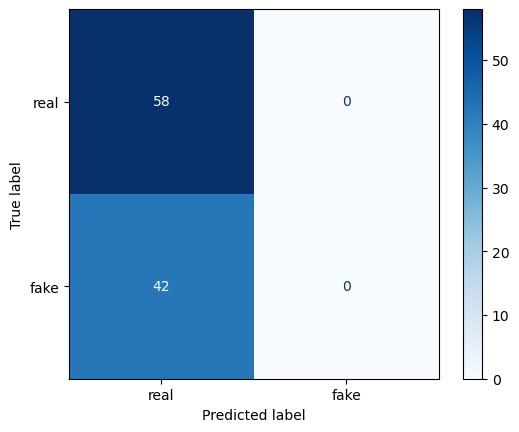

In [22]:
cm = confusion_matrix(val_sample["label"], predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["real", "fake"])
disp.plot(cmap="Blues")
plt.show()